<p style="text-align: center;">
<font size="5">
Сравнение open-source солверов для задач ритейла

<p style="text-align: justify;">
В прикладных бизнес-задачах часто встречаются формулировки вида "максимизируй одну метрику при сохранении другой"; к этой формулировке обычно добавляется ряд правил и зависимостей, которые также необходимо учитывать в алгоритмах. Подобные задачи относятся к области <a href="https://en.wikipedia.org/wiki/Operations_research">исследования операций</a> и решаются с помощью оптимизаторов (солверов). На начальной стадии проекта (MVP) обычно используется первый попавшийся солвер, нам на практике встречались даже реализации в Excel, что для MVP-решения является нормальным подходом. Однако при дальнейшем масштабировании задачи, время поиска решения может сильно возрасти, и чтобы уложиться в приемлемое расчётное время, приходится подбирать другой солвер. В этой статье мы рассмотрим несколько открытых солверов, сравним их возможности и скорость работы на модельной задаче ценообразования.

Существует большое множество формулировок бизнес-задач, которые можно решать оптимизаторами, приведём 3 примера из ритейла. 

***1. Ценообразование***
<p style="text-align: justify;">
Необходимо найти оптимальную конфигурацию цен с учетом ценового позиционирования, допустимых ценовых диапазонов для каждого товара и набора бизнес-ограничений. Цены должны максимизировать суммарный доход, а прибыль быть не ниже на заданного уровня.

***2. Оптимальное распределение маркетингового бюджета***
<p style="text-align: justify;">
Распределить маркетинговый бюджет максимально эффективно, при этом: учесть разные каналы для рекламных акций, правила на количество коммуникаций, отклик пользователей на каждый вид коммуникации, ограничение на общую нагрузку каждого канала и множество других ограничений.

***3. Закупка товаров***

<p style="text-align: justify;">
Распределить бюджет, выделенный на закупки, для поддержания товарооборота, достаточного уровня сервиса, и при этом достигать определенных финансовых показателей под выделенный бюджет на закупки.


***Поучительный пример***

<p style="text-align: justify;">
Иногда оптимальным решением является творческий взгляд на проблему. Например, чтобы снизить количество жалоб на длительное ожидание лифта лучшим решением оказалось добавление зеркал, а не оптимизация загрузки лифтов.

<p style="text-align: justify;">
В любом случае, для успешного решения подобных задач необходимо тесное взаимодействие с экспертами-заказчиками и исследование проблемы в “полях”.

## Модель и What-If

Как было сказано выше, будем сравнивать солверы для задачи ценообразования. 
Для этого придумаем модельную задачу, чтобы не нарушать NDA.

Предположим, что спрос $Q$ на товар зависит только от цены $P$ и определяется следующей моделью:
\begin{equation}
\tag{1}
Q=Q_{0}exp\left(E\left(\frac{P_0}{P}-1\right)\right),
\end{equation}

где $Q_{0}$ - бекущий спрос на товар, $E$ - эластичность спроса от цены, $P_{0}$ - текущая цена.


**Небольшое отступление**

<p style="text-align: justify;">    
Часто бизнес-заказчик ограничивается только <b>What-If</b> анализом для выбора лучших значений цены.
What-If для модели (1) позволяет найти набор цен для каждого товара, либо для заданной руками цены оценить $Q$.    
Основная проблема перебора цен с what-if - объём ручной работы и сложность в учёте бизнес-ограничений.

Рассмотрим пример, когда ставится задача поднять суммарные продажи категории товаров на 2%.
Пусть категория содержит N уникальных sku, мы знаем эластичность E для каждого товара, тогда мы получим следующее решение, решая задачу для каждого товара независимо:

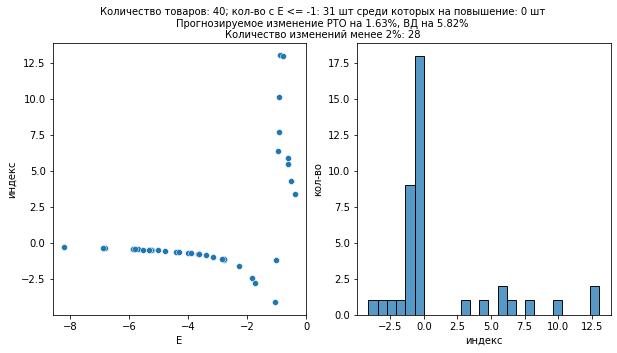

In [1]:
from data_generator.what_if import sim_data, plot_what_if
plot_what_if(sim_data());

<p style="text-align: justify;">
Хорошо видно, что для чувствительных товаров (E<-1) новая цена, выраженная через индекс относительно старой цены, снизится, и наоборот. Модель предлагает для 28 (из 40) товаров изменить цену менее, чем на 2%, что может противоречить бизнес-ограничению на минимально допустимое изменение цены, или нивелироваться округлением цены по бизнес-правилам, например, заканчиваться на x.99 копеек.
Таким образом, подобный подход нам не подходит, т.к. не учитывает ограничение на минимальное изменение цены, также не хотелось бы загружать менеджеров дополнительной ручной работой для подобных проверок.

## Общая постановка задачи оптимизации

$$f(x) \rightarrow \min_{x}$$
$$g_{i}(x) \le 0, i=1..n,$$
$$h_{i}(x) = 0, i=1..m,$$
$$x \in X$$

$f(x)$ функция от цены см. (1), выраженной через ценовой индекс от текущей цены, $g$ и $h$ зависимости, отражающие бизнес-ограничения.

## Какие есть оптимизаторы?

Общая постановка задачи

Описание видов оптимизационных задач(постановки)


Рассмотрим полезные open-source пакеты и солверы для решения задач условной оптимизации в зависимости от ее типа, которые часто можно встретить в практических задачах

| Солвер(метод) | Пакеты в python | NLP | LP | MILP | MINLP |
|:-------------:|:---------------:|:---:|:--:|:----:|:-----:|
|     cobyla    |      scipy      |  y  |  y |   n  |    n  |
|     slsqp     |      scipy      |  y  |  y |   n  |    n  |
|  trust-constr |      scipy      |  y  |  y |   n  |    n  |
|     ipopt     |      pyomo      |  y  |  y |   n  |    n  |
|      glpk     |   pyomo, cvxpy  |  n  |  y |   y  |    n  |
|      cbc      |   pyomo, cvxpy  |  n  |  y |   y  |    n  |
|      ecos     |      cvxpy      |  y  |  y |   y  |   y   |
|     bonmin    |      pyomo      |  y  |  y |   y  |    y  |

Открытые библиотеки, предоставляющие интерфейс для решения оптимизационных задач

**Scipy** - библиотека, которая содержит большой набор функций для научных вычислений, в том числе имеет инструменты для решения оптимизационных задач, находящиеся в модуле scipy.optimize. В модуле находятся методы для решения задач линейного программирования, нелинейного программирования(как условная так и безусловная). 

**Pyomo** - пакет, который содержит кучу инструментов для формулирования, решения и анализа оптимизационных моделей. Главная особенность - это удобный интерфейс для структурированного формулирования оптимизационной задачи и поддержка большого количества солверов, в том числе коммерческих. По сути пакет занимается “перевариванием” сформулированной модели в формат, понятный для запускаемого солвера, в большинстве случаев с помощью AMPL, который генерирует .nl файл для солвера.

**Cvxpy** - идейно данный пакет похож на pyomo, но данный пакет специально заточен для решения задач выпуклой оптимизации. После того как задача сформулирована, перед решением проверяется выпуклость и аффинность целевой функции и ограничений помощью правил DCP(disciplined convex programming), после проверки задача преобразуется в стандартную форму и передается квадратичному или коническому солверу, также возможно подключение коммерческого солвера.

Солверы
* cobyla - 
* slsqp - 
* trust-constr - 
* ipopt - 
* glpk - 
* cbc - 
* ecos - 
* bonmin - 




Пример использования пакетов на python

описание пайплайна для задачи оптимизации в ЦО


In [3]:
%load_ext autoreload
%autoreload 2
%load_ext autotime

time: 366 µs (started: 2022-07-13 23:39:53 +03:00)


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys

sys.path.append('./OptimizersArticle')
from runner import DATA_DUMP, GRID, bounds_params, CvxpyLpOptimizationModel
from runner import optimizers_collect_stat, optimizers_calculate_stat


from data_generator.data_generator import (
    generate_data,
    construct_bounds,
    construct_lp_grid
)

from optimizers.optimization import pricing_optimization


time: 515 ms (started: 2022-07-13 23:39:54 +03:00)


In [5]:
optimizers_calculate_stat(GRID, DATA_DUMP)

time: 179 ms (started: 2022-07-13 23:39:55 +03:00)


In [6]:
stats_df = optimizers_collect_stat('./data/dump.hdf')

time: 1.66 s (started: 2022-07-13 23:39:55 +03:00)


### Отчет по времени работы и количеству "успешно" решенных задач

In [7]:
if 'stats_df' not in globals():
    stats_df = pd.read_csv('./data/optimizers_stats.csv')
stats_df['success'] = stats_df['status'] == 'ok'
time_rep_df = stats_df.groupby(['solver', 'N'])['t'].describe().reset_index()
stats_df

,N,seed,solver,t,status,success
0,10,0,slsqp,0.011506,ok,True
1,10,0,trust-constr,0.250120,ok,True
2,10,0,ipopt,0.045246,ok,True
3,10,0,pyomo_cbc,0.071532,ok,True
4,10,0,pyomo_glpk,0.041340,ok,True
...,...,...,...,...,...,...
2,500,9,pyomo_cbc,2.380126,ok,True
3,500,9,pyomo_glpk,1.047312,ok,True
4,500,9,cvxpy_cbc,0.626378,ok,True
5,500,9,cvxpy_glpk,1.105780,ok,True


time: 98.7 ms (started: 2022-07-13 23:39:57 +03:00)


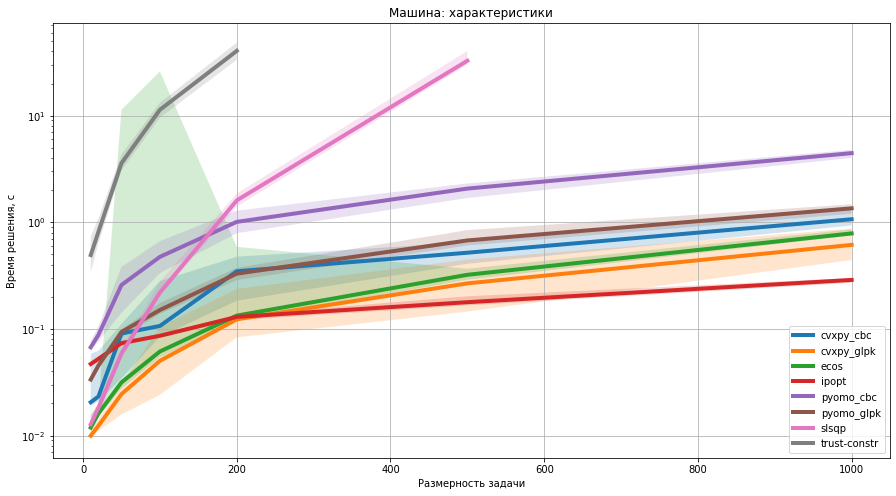

time: 547 ms (started: 2022-07-13 23:39:57 +03:00)


In [8]:
plt.figure(figsize=(15, 8))
for solver, df in time_rep_df.groupby(['solver']):
    plt.plot(df['N'], df['50%'], label=solver, lw=4)
    plt.fill_between(df['N'], df['25%'], df['75%'], alpha=0.2)
plt.yscale('log')
# plt.xscale('log')
plt.legend()
plt.xlabel('Размерность задачи')
plt.ylabel('Время решения, с')
plt.grid()
plt.title("Машина: характеристики")
plt.show()


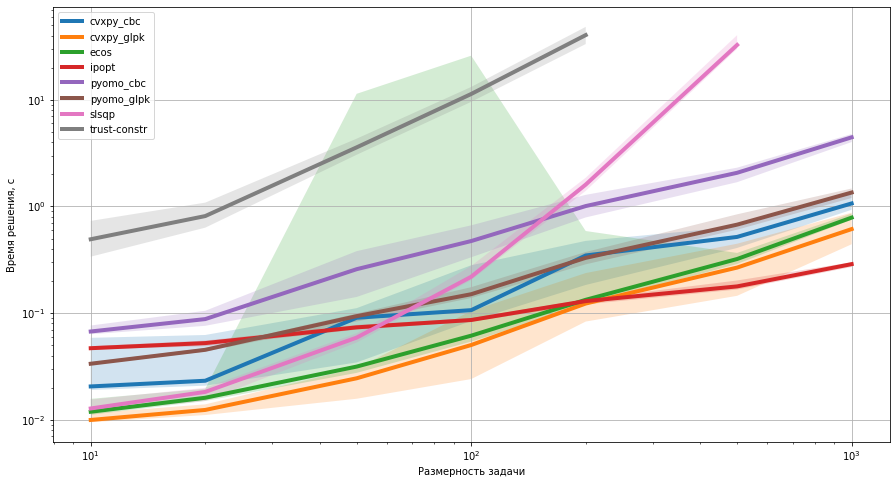

time: 555 ms (started: 2022-07-13 23:39:58 +03:00)


In [9]:
plt.figure(figsize=(15, 8))
for solver, df in time_rep_df.groupby(['solver']):
    plt.plot(df['N'], df['50%'], label=solver, lw=4)
    plt.fill_between(df['N'], df['25%'], df['75%'], alpha=0.2)
plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.xlabel('Размерность задачи')
plt.ylabel('Время решения, с')
plt.grid()
plt.show()


In [10]:
stats_df.groupby(['solver'])['success'].mean()

solver
cvxpy_cbc       1.000000
cvxpy_glpk      1.000000
ecos            0.777143
ipopt           1.000000
pyomo_cbc       1.000000
pyomo_glpk      1.000000
slsqp           1.000000
trust-constr    0.984000
Name: success, dtype: float64

time: 3.88 ms (started: 2022-07-13 23:39:58 +03:00)


In [11]:
# stats_df.query("not success")

time: 504 µs (started: 2022-07-13 23:39:58 +03:00)


In [12]:
# data_c = generate_data(10, 1)
# data_c = construct_bounds(data_c, bounds_params)
# # генерация данных для MILP оптимизации
# data_d = construct_lp_grid(data_c, bounds_params, 21)
# M_cur = sum(data_c['Q'] * (data_c['P'] - data_c['C']))
# P_cur = sum(data_c['Q'] * data_c['P'])

# opt_params = {
#     'alpha': 0.0,
#     'con_mrg': M_cur,
#     'con_equal': True
# }

time: 641 µs (started: 2022-07-13 23:39:58 +03:00)


In [13]:
# %%time
# res_cvx, t_cvx = pricing_optimization(data_d, CvxpyLpOptimizationModel, opt_params, 'ECOS_BB',
#                                       solver_option={'max_iters': 1000})
# # res_cbc, t_cbc = pricing_optimization(data_d, PyomoLpOptimizationModel, opt_params, 'glpk')

time: 605 µs (started: 2022-07-13 23:39:58 +03:00)
